# Task 3 — Demand Forecasting with Support Vector Regression

This notebook trains a **Support Vector Regression (SVR)** model to forecast taxi demand — the number of pickups (`trip_count`) per H3 hexagon and time bucket.

The model-ready panel comes from `prepare_modelling(resolution, freq)`, the shared entry point that loads the cleaned trips, aggregates them to the (hexagon × time-bucket) grid, and appends the calendar, cyclic, and weather features. Routing both this notebook and the neural-network notebook through the same function guarantees they see an identical target and feature set, so any performance gap reflects the model, not the data preparation.

**Constraint:** the assignment forbids lag / autoregressive demand features, so spatial signal comes from *static* encodings (one-hot `h3_id`) rather than past demand.

**Outline:**
1. **Train/test split** — build the feature matrix and target, random train / validation / test split.
2. **Kernel & hyperparameter tuning** — start from a linear kernel and progressively add complexity (polynomial, RBF), tuning `C` / `gamma` / `epsilon` per kernel on the validation set.
3. **Final evaluation** — score the best overall configuration once on the held-out test set against per-cell-mean and climatology baselines.
4. **Predicted vs. actual & where the error lives** — visualise fit quality, break the error down by time of day, demand level, and hexagon, and map the worst hexagons onto Chicago.
5. **Spatial / temporal resolution sensitivity** — sweep H3 resolution 5–7 and time-bucket width 1h/3h to see how performance moves.
6. **Shortfalls & potential improvements** — what the model still gets wrong, and what a follow-up project could try next.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import product

path = os.getcwd()
while ".git" not in os.listdir(path):
    path = os.path.dirname(path)
ROOT_DIR = Path(path)
os.chdir(ROOT_DIR)

from scripts.helpers.modelling import prepare_modelling

In [2]:
df = prepare_modelling(resolution=6, freq='3h')
display(df.head())
df.info()

,h3_id,time_bucket,trip_count,is_weekend,is_holiday,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,...,windspeed_10m,windgusts_10m,cloud_cover,n_poi_accommodation,n_poi_education,n_poi_entertainment,n_poi_food_nightlife,n_poi_healthcare,n_poi_shopping,n_poi_transport
0,862664197ffffff,2024-01-01 00:00:00,0,False,True,0.0,1.0,0.0,1.0,0.0,...,30.300000,45.7,100.000000,0,10,1,27,4,7,1
1,862664197ffffff,2024-01-01 03:00:00,0,False,True,0.707107,0.707107,0.0,1.0,0.0,...,25.433333,43.6,100.000000,0,10,1,27,4,7,1
2,862664197ffffff,2024-01-01 06:00:00,0,False,True,1.0,0.0,0.0,1.0,0.0,...,22.566667,33.8,88.333333,0,10,1,27,4,7,1
3,862664197ffffff,2024-01-01 09:00:00,0,False,True,0.707107,-0.707107,0.0,1.0,0.0,...,16.300000,29.5,10.333333,0,10,1,27,4,7,1
4,862664197ffffff,2024-01-01 12:00:00,0,False,True,0.0,-1.0,0.0,1.0,0.0,...,13.200000,24.8,26.000000,0,10,1,27,4,7,1


<class 'pandas.DataFrame'>
RangeIndex: 177008 entries, 0 to 177007
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   h3_id                 177008 non-null  string        
 1   time_bucket           177008 non-null  datetime64[us]
 2   trip_count            177008 non-null  int64         
 3   is_weekend            177008 non-null  bool          
 4   is_holiday            177008 non-null  bool          
 5   hour_sin              177008 non-null  Float64       
 6   hour_cos              177008 non-null  Float64       
 7   day_of_week_sin       177008 non-null  Float64       
 8   day_of_week_cos       177008 non-null  Float64       
 9   month_sin             177008 non-null  Float64       
 10  month_cos             177008 non-null  Float64       
 11  temperature_2m        177008 non-null  float64       
 12  apparent_temperature  177008 non-null  float64       
 13  precipitat

### Train / Hold / Test Split

**Target — `log1p(trip_count)`.** Demand is a heavily zero-inflated, right-skewed count, so the log scale stabilises the variance and keeps the SVR's loss on an interpretable scale (invert predictions with `np.expm1`).

**Spatial information — one-hot hexagon id.** `prepare_modelling` carries calendar and weather features but nothing about *where* a cell is, so on its own the model would predict the same demand for every hexagon at a given time. With a fixed set of 26 cells and no lag features allowed, one-hot encoding `h3_id` is the most direct, leakage-free way to give each cell its own learned demand baseline. The raw `h3_id` / `time_bucket` stay out of the feature matrix (kept in `ids` for later attribution), and the integer time fields are dropped in favour of their cyclic encodings.

**Split — random 50 / 20 / 30.** Rows are shuffled and assigned 50 % train, 20 % validation (`hold`, used for tuning), 30 % test. Note this is *not* a forecasting split: because the shuffle mixes time buckets across the three sets, the same period appears in both train and test, so the model effectively sees demand from the test period during training. That removes the train→test level gap (and the systematic under-prediction it caused) but inflates the reported skill relative to a true out-of-sample forecast — the numbers below should be read as an upper bound, not a forecasting estimate. The neural-network notebook mirrors this exact split (same proportions, same `random_state`) so the two models are compared on identical train/test rows.

In [3]:
# Target: log1p of the count — demand is heavily zero-inflated and right-skewed,
# so a log scale stabilises the variance. Invert predictions later with np.expm1.
y = np.log1p(df['trip_count'])

ID_cols = ['h3_id', 'time_bucket']
ids = df[ID_cols]  # kept aside for attribution / inversion

# Spatial information: one-hot encode the hexagon id so the model learns a
# per-cell demand baseline. With a fixed set of 26 cells and no lag features
# allowed, this is the most direct, leakage-free spatial encoding.
hex_dummies = pd.get_dummies(df['h3_id'], prefix='hex', dtype=float)

# Feature matrix: drop ids + target, drop the integer time fields already
# represented by their cyclic (sin/cos) encodings, then append the spatial dummies.
x = pd.concat(
    [df.drop(columns=['trip_count', *ID_cols]),
     hex_dummies],
    axis=1,
)

# Random 50 / 20 / 30 train / validation / test split (rows shuffled across time).
# NB: this is NOT a forecasting split — shuffling mixes time buckets between train and
# test, so the same period appears on both sides and the reported error is optimistic
# relative to a true out-of-sample forecast.
from sklearn.model_selection import train_test_split

train_idx, temp_idx = train_test_split(df.index, train_size=0.50, random_state=42, shuffle=True)
hold_idx,  test_idx = train_test_split(temp_idx, train_size=0.40, random_state=42, shuffle=True)  # 0.40 * 0.50 = 0.20 hold, 0.30 test

x_train, y_train = x.loc[train_idx], y.loc[train_idx]
x_hold,  y_hold  = x.loc[hold_idx],  y.loc[hold_idx]
x_test,  y_test  = x.loc[test_idx],  y.loc[test_idx]

print(f"train {len(x_train):>7,}  ({len(x_train) / len(df):.0%})")
print(f"hold  {len(x_hold):>7,}  ({len(x_hold) / len(df):.0%})")
print(f"test  {len(x_test):>7,}  ({len(x_test) / len(df):.0%})")

train  88,504  (50%)
hold   35,401  (20%)
test   53,103  (30%)


## Kernel Progression & Hyperparameter Tuning

Per the assignment, we start from a **linear kernel** and progressively add complexity: `linear` → `poly` → `rbf`. We fold this into the same grid search that tunes `C` / `gamma` / `epsilon`, so the kernel choice is just one more axis of the grid rather than a separate step — every config is fit and scored the same way, by MAE (original trip counts) on the `hold` validation set.

Four practical points:

- **`gamma` has no effect for `kernel='linear'`** (sklearn ignores it), so the linear rows of the grid only vary `C` and `epsilon` — sweeping `gamma` for them would just refit the same model repeatedly.
- **The linear-kernel solver is markedly slower** than RBF/poly at this sample size (libsvm's linear solver scales worse with rows here), so linear is tuned on a smaller subsample than poly/rbf to keep total runtime reasonable.
- **`max_iter` is capped** for every fit. Without a cap, some `poly` configurations below never converge — the degree-3 polynomial kernel on ~50 standardised features explodes numerically for anything but a tiny `gamma`, so the underlying optimisation problem is badly conditioned and the solver can run effectively forever chasing it. Capping `max_iter` bounds worst-case runtime; the affected configurations simply score very poorly on the hold set and sort to the bottom, which is itself the expected result of "progressively adding complexity" — `poly` is markedly less numerically robust than `rbf` on this feature set, not just slower.
- We standardise the features first (SVR is distance-based, so unscaled inputs would let the widest-range columns dominate the kernel), and tune on fixed random subsamples of the training set rather than the full ~92k rows, since RBF/poly SVR scale roughly `O(n²)`.

In [4]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.exceptions import ConvergenceWarning
import warnings

# RBF/poly SVR is O(n^2) in the training rows, so tune on fixed random subsamples
# of the (shuffled) training set and validate on the hold set. Linear gets a smaller
# subsample because its solver is markedly slower at a given row count here.
TUNE_N         = 8_000
TUNE_N_LINEAR  = 3_000
MAX_ITER       = 20_000   # bounds worst-case runtime; see markdown above (poly's numerical instability)
rng = np.random.RandomState(1)

def tune_set(n):
    idx = rng.choice(x_train.index, size=min(n, len(x_train)), replace=False)
    return x_train.loc[idx].astype(float), y_train.loc[idx]   # cast nullable Int64/bool -> float for the scaler

X_tune,     y_tune     = tune_set(TUNE_N)
X_tune_lin, y_tune_lin = tune_set(TUNE_N_LINEAR)
X_hold = x_hold.astype(float)

def mae_counts(model, X, y_log):
    """Mean absolute error in original trip counts (invert the log1p target)."""
    return mean_absolute_error(np.expm1(y_log), np.expm1(model.predict(X)))

# Linear: gamma is a no-op, so only C / epsilon vary. Poly/rbf: full C x gamma x epsilon grid.
linear_grid = [
    {'kernel': 'linear', 'C': C, 'epsilon': eps}
    for C, eps in product([0.1, 1, 10, 100], [0.1, 0.2])
]
nonlinear_grid = [
    {'kernel': k, 'C': C, 'gamma': g, 'epsilon': eps}
    for k, C, g, eps in product(['poly', 'rbf'], [0.1, 1, 10, 100], ['scale', 0.1, 0.01], [0.1, 0.2])
]

rows = []
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category=ConvergenceWarning)  # expected for the unstable poly configs
    for params in linear_grid + nonlinear_grid:
        Xt, yt = (X_tune_lin, y_tune_lin) if params['kernel'] == 'linear' else (X_tune, y_tune)
        model = make_pipeline(StandardScaler(), SVR(max_iter=MAX_ITER, **params))
        model.fit(Xt, yt)
        rows.append({**params, 'hold_MAE': mae_counts(model, X_hold, y_hold)})

tuning_results = pd.DataFrame(rows).sort_values('hold_MAE').reset_index(drop=True)
best = tuning_results.iloc[0]
print(f"best overall: kernel={best.kernel}, C={best.C}, gamma={best.get('gamma', '-')}, "
      f"epsilon={best.epsilon}  ->  hold MAE {best.hold_MAE:.3f}")

# Best config per kernel — makes the linear -> poly -> rbf progression explicit.
tuning_results.loc[tuning_results.groupby('kernel')['hold_MAE'].idxmin()].fillna('-').round(3)

best overall: kernel=rbf, C=10.0, gamma=scale, epsilon=0.1  ->  hold MAE 14.916


,kernel,C,epsilon,hold_MAE,gamma
27,linear,1.0,0.2,24.140,-
14,poly,1.0,0.2,19.733,0.01
0,rbf,10.0,0.1,14.916,scale


## Final Evaluation on the Test Set

We refit the best overall configuration on the combined **train + validation** rows (subsampled for tractability) and score it **once** on the held-out test set. Because the split is random rather than chronological, these test buckets are interleaved in time with the training buckets, so this is an *in-distribution* estimate, not an out-of-sample forecast — read the numbers as an upper bound on forecasting skill.

Several metrics are reported in trip-count units: **MAE** and **RMSE** (RMSE punishes the large misses on busy cells), **median absolute error** (robust to that heavy tail), **R²** (variance explained), and **bias** (mean signed error — the `log1p`→`expm1` round-trip tends to under-predict, so a slightly negative bias is expected before correction. We fix that with **Duan smearing**: scale `exp(prediction)` by the mean exponentiated fit-set residual, which removes most of the systematic under-prediction while keeping the log's variance stabilisation.

Two no-model baselines set the bar:

- **per-cell mean** — each hexagon's average training demand (spatial signal, no time).
- **climatology** — per (cell, hour-of-day, weekend) average, a strong *seasonal* naive forecast.

The **skill score** (`1 − MSE_model / MSE_baseline`) summarises how much error the SVR removes over each baseline; a positive value against *climatology* is what genuinely justifies the model over simple averaging.

In [5]:
from sklearn.metrics import mean_squared_error, median_absolute_error, r2_score

# Refit the best overall configuration on train + hold (subsampled), then score ONCE
# on the test set. gamma is only meaningful for poly/rbf, so it's omitted for linear.
FIT_N = 30_000
fit_pool = x_train.index.union(x_hold.index)
fit_idx = rng.choice(fit_pool, size=min(FIT_N, len(fit_pool)), replace=False)

X_fit = pd.concat([x_train, x_hold]).loc[fit_idx].astype(float)
y_fit = pd.concat([y_train, y_hold]).loc[fit_idx]

svr_kwargs = dict(kernel=best.kernel, C=float(best.C), epsilon=float(best.epsilon), max_iter=MAX_ITER)
if best.kernel != 'linear':
    svr_kwargs['gamma'] = best.gamma

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category=ConvergenceWarning)
    final_svr = make_pipeline(StandardScaler(), SVR(**svr_kwargs))
    final_svr.fit(X_fit, y_fit)

# Predict on the test set in log space, then back-transform to trip counts.
true_test = np.expm1(y_test).to_numpy()
zhat_test = final_svr.predict(x_test.astype(float))
pred_svr  = np.expm1(zhat_test)                       # naive back-transform

# Duan smearing correction: expm1() of a mean log-prediction under-predicts the
# (right-skewed) count. Scaling by the mean exponentiated
# fit-set residual removes that systematic bias while keeping the log's variance
# stabilisation:  pred = exp(zhat) * E[exp(resid)] - 1.
resid_fit = y_fit.to_numpy() - final_svr.predict(X_fit)
smear = float(np.mean(np.exp(resid_fit)))
pred_svr_smear = np.exp(zhat_test) * smear - 1

# --- No-model baselines, both built only from the training window ---
train_counts = np.expm1(y_train)

# 1. Per-cell mean: each hexagon's average demand (spatial signal, no time).
cell_mean = train_counts.groupby(ids.loc[x_train.index, 'h3_id'].to_numpy()).mean()
pred_cell = ids.loc[x_test.index, 'h3_id'].map(cell_mean).to_numpy()

# 2. Climatology: per (cell, hour-of-day, weekend) mean — a strong seasonal naive
#    forecast. Beating THIS is what justifies a model over simple averaging.
def keys(index):
    tb = ids.loc[index, 'time_bucket'].dt
    return pd.DataFrame({'h3_id': ids.loc[index, 'h3_id'].to_numpy(),
                         'hour':  tb.hour.to_numpy(),
                         'wknd':  (tb.dayofweek >= 5).to_numpy()}, index=index)

ktr = keys(x_train.index); ktr['count'] = train_counts.to_numpy()
clim = ktr.groupby(['h3_id', 'hour', 'wknd'])['count'].mean()
pred_clim = (keys(x_test.index)
             .join(clim.rename('clim'), on=['h3_id', 'hour', 'wknd'])['clim']
             .fillna(train_counts.mean())     # fallback for combos unseen in training
             .to_numpy())

def report(name, pred):
    pred = np.asarray(pred, dtype=float)
    return {'model': name,
            'MAE':   mean_absolute_error(true_test, pred),
            'RMSE':  mean_squared_error(true_test, pred) ** 0.5,
            'MedAE': median_absolute_error(true_test, pred),
            'R2':    r2_score(true_test, pred),
            'bias':  float(np.mean(pred - true_test))}   # +ve = systematic over-prediction

scores = pd.DataFrame([
    report('per-cell mean', pred_cell),
    report('climatology (cell x hour x weekend)', pred_clim),
    report(f'SVR ({best.kernel}, C={best.C})', pred_svr),
    report(f'SVR ({best.kernel}) + smearing', pred_svr_smear),
]).set_index('model').round(3)

# Skill score: fraction of a baseline's MSE the model removes (>0 = adds value).
mse = lambda p: mean_squared_error(true_test, p)
print(f"refit on {len(fit_idx):,} rows  |  tested on {len(x_test):,} rows  |  smearing factor {smear:.3f}")
print(f"SVR skill vs per-cell mean: {1 - mse(pred_svr_smear)/mse(pred_cell):+.3f}"
      f"   |   vs climatology: {1 - mse(pred_svr_smear)/mse(pred_clim):+.3f}")
scores

refit on 30,000 rows  |  tested on 53,103 rows  |  smearing factor 1.107
SVR skill vs per-cell mean: +0.597   |   vs climatology: -0.719


,MAE,RMSE,MedAE,R2,bias
model,,,,,
per-cell mean,26.767,113.907,0.062,0.521,0.125
climatology (cell x hour x weekend),11.105,55.114,0.026,0.888,0.615
"SVR (rbf, C=10.0)",11.282,65.728,0.101,0.840,-1.717
SVR (rbf) + smearing,12.253,72.267,0.185,0.807,1.691


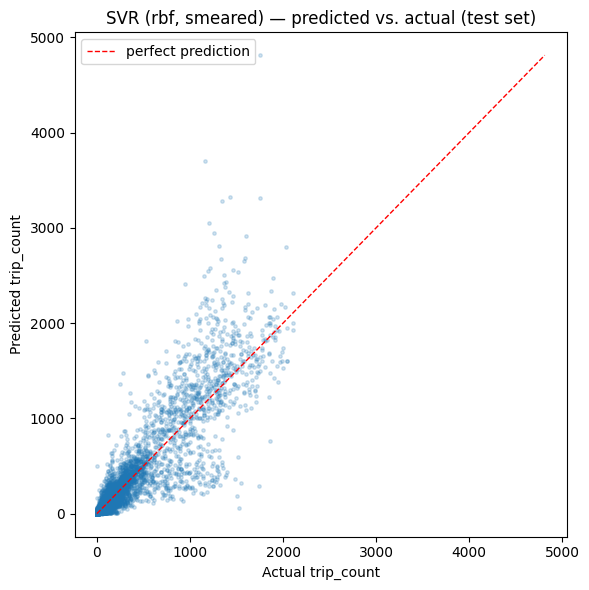

In [6]:
# Predicted vs. actual on the test set: points on the diagonal are perfect.
lim = max(true_test.max(), pred_svr_smear.max())
plt.figure(figsize=(6, 6))
plt.scatter(true_test, pred_svr_smear, s=6, alpha=0.2)
plt.plot([0, lim], [0, lim], 'r--', lw=1, label='perfect prediction')
plt.xlabel('Actual trip_count')
plt.ylabel('Predicted trip_count')
plt.title(f'SVR ({best.kernel}, smeared) — predicted vs. actual (test set)')
plt.legend()
plt.tight_layout()
plt.show()

## Where the Error Lies

A single MAE hides *where* the model struggles. We break the test absolute error down by **time of day**, by **demand level**, and by **hexagon**. Forecasters of this kind are typically accurate on quiet cells and bleed most of their error on a handful of very high-traffic ones (airports, downtown) — which matters more for operations than the headline average.

Test MAE by demand level (counts):
          mean   size
true                 
0-1       0.31  41994
1-5       3.51   2462
5-20      7.34   2733
20-100   22.89   3173
100+    195.70   2741


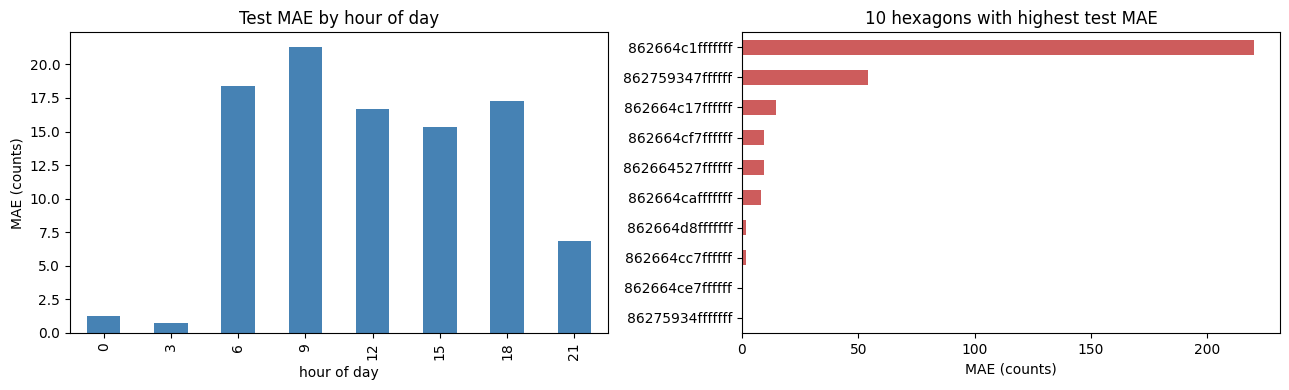

In [7]:
# Test-set residuals, sliced by time of day, demand level, and hexagon.
res = pd.DataFrame({
    'true':  true_test,
    'pred':  pred_svr_smear,
    'h3_id': ids.loc[x_test.index, 'h3_id'].to_numpy(),
    'hour':  ids.loc[x_test.index, 'time_bucket'].dt.hour.to_numpy(),
})
res['abs_err'] = (res['pred'] - res['true']).abs()

# MAE by demand level: shows the error concentrates in the busy buckets.
by_level = res.groupby(
    pd.cut(res['true'], [-0.1, 1, 5, 20, 100, np.inf],
           labels=['0-1', '1-5', '5-20', '20-100', '100+']),
    observed=False,
)['abs_err'].agg(['mean', 'size']).round(2)
print('Test MAE by demand level (counts):')
print(by_level)

by_hour = res.groupby('hour')['abs_err'].mean()
worst   = res.groupby('h3_id')['abs_err'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
by_hour.plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set(title='Test MAE by hour of day', xlabel='hour of day', ylabel='MAE (counts)')
worst.plot(kind='barh', ax=ax[1], color='indianred')
ax[1].set(title='10 hexagons with highest test MAE', xlabel='MAE (counts)', ylabel='')
ax[1].invert_yaxis()
plt.tight_layout()
plt.show()

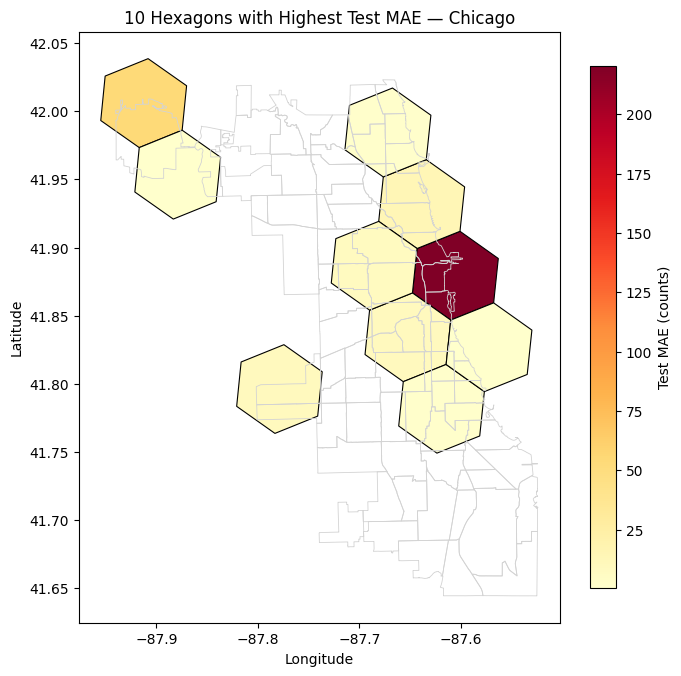

In [8]:
# Map the 10 worst hexagons from above onto Chicago, colour intensity = test MAE.
import geopandas as gpd
import h3
from shapely.geometry import Polygon

gdf_communities = gpd.read_file(ROOT_DIR / 'data' / 'raw' / 'community_areas.geojson')

worst_geo = gpd.GeoDataFrame(
    {'h3_id': worst.index, 'MAE': worst.values},
    geometry=[Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(h)]) for h in worst.index],
    crs='EPSG:4326',
)

fig, ax = plt.subplots(figsize=(7, 9))
gdf_communities.boundary.plot(ax=ax, color='lightgray', linewidth=0.6)
worst_geo.plot(ax=ax, column='MAE', cmap='YlOrRd', edgecolor='black', linewidth=0.8,
               legend=True, legend_kwds={'label': 'Test MAE (counts)', 'shrink': 0.6})
ax.set_title('10 Hexagons with Highest Test MAE — Chicago')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## Spatial & Temporal Resolution Sensitivity

The assignment also asks how performance changes with different spatial and temporal resolutions. We sweep the full grid of **H3 resolution ∈ {5, 6, 7}** × **time-bucket width ∈ {1h, 3h}** (6 combinations), reusing the already-tuned `(kernel, C, gamma, epsilon)` from the grid search above rather than re-tuning per combination — re-running the full grid search 6 times would multiply the runtime cost considerably.

`prepare_modelling` rebuilds the whole panel from the raw trip table on every call (it re-reads and re-aggregates ~6.6M trips, with no caching besides the per-resolution POI features), so this is the dominant cost of this section: 6 calls in total (one of which, `resolution=6, freq='3h'`, reuses the panel already loaded above). The first call at resolution 5 or 7 additionally triggers a one-time POI fetch from OpenStreetMap (no cache exists yet for those resolutions), so those two are slower only the first time they run.

**Why R² and MAPE, not raw MAE.** Finer hexagons and narrower time buckets mechanically have *smaller* typical demand per cell-bucket, so raw MAE shrinks with resolution even if the model's actual skill is unchanged or worse — it's not a fair like-for-like comparison. **R²** and **MAPE** are scale-independent and therefore comparable across configurations; we still report MAE alongside them for reference. MAPE is undefined at zero actual demand, which is common in this zero-inflated target, so it is computed over the non-zero-demand rows only (a standard convention).

**A second, unrelated data issue surfaces only at `freq='1h'`:** exactly 3 hourly timestamps per year are missing weather data after the join (a tiny fraction of rows — e.g. 78 out of 531,024 at resolution 6), most likely a daylight-saving-time artifact on the weather side, mirroring the already-documented DST issue on the trip-timestamp side. It was never visible at the project's usual `freq='3h'`/`'4h'` widths because those buckets absorb the missing hour. Affected rows are dropped before fitting.

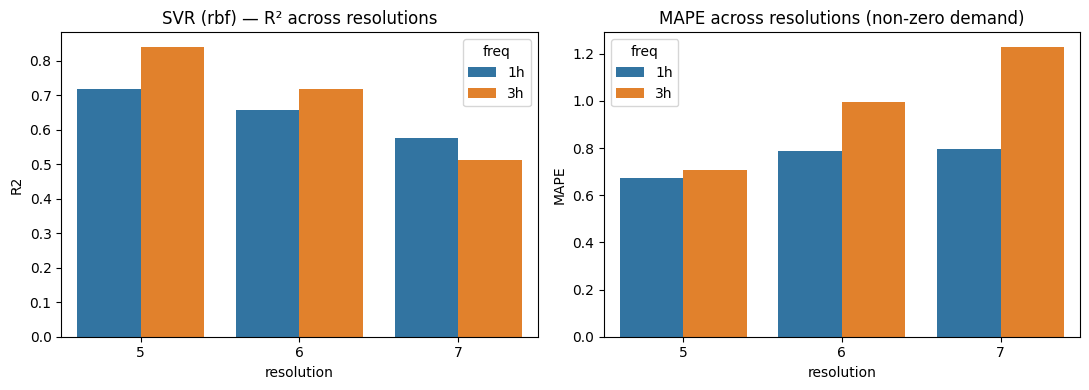

,resolution,freq,n_rows,n_hex,MAE,R2,MAPE
0,5,1h,163392,8,15.219,0.720,0.673
1,5,3h,54464,8,36.979,0.841,0.706
2,6,1h,531024,26,6.496,0.657,0.789
3,6,3h,177008,26,16.250,0.719,0.994
4,7,1h,2226216,109,1.405,0.577,0.797
5,7,3h,742072,109,4.994,0.512,1.229


In [9]:
from sklearn.metrics import mean_absolute_percentage_error

def quick_score(panel, n=6_000, seed=1):
    """Fit the already-tuned SVR on a small subsample of `panel`; return MAE, R2, and MAPE."""
    yy = np.log1p(panel['trip_count'])
    hex_d = pd.get_dummies(panel['h3_id'], prefix='hex', dtype=float)
    xx = pd.concat([panel.drop(columns=['trip_count', 'h3_id', 'time_bucket']), hex_d], axis=1)

    # A handful of hourly timestamps are missing weather data (DST artifact, see
    # markdown above) only at freq='1h'; drop those rows rather than fix the shared
    # weather pipeline for a ~0.01% slice of rows.
    valid = xx.notna().all(axis=1)
    xx, yy = xx.loc[valid], yy.loc[valid]

    tr_idx, te_idx = train_test_split(xx.index, train_size=0.7, random_state=42, shuffle=True)
    rng2 = np.random.RandomState(seed)
    tr_sub = rng2.choice(tr_idx, size=min(n, len(tr_idx)), replace=False)
    te_sub = rng2.choice(te_idx, size=min(n // 2, len(te_idx)), replace=False)

    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=ConvergenceWarning)
        model = make_pipeline(StandardScaler(), SVR(**svr_kwargs))
        model.fit(xx.loc[tr_sub].astype(float), yy.loc[tr_sub])
    pred = np.expm1(model.predict(xx.loc[te_sub].astype(float)))
    true = np.expm1(yy.loc[te_sub]).to_numpy()

    nonzero = true > 0   # MAPE is undefined at true == 0, which is common in this zero-inflated target
    return {
        'n_rows': len(panel), 'n_hex': panel['h3_id'].nunique(),
        'MAE':  mean_absolute_error(true, pred),
        'R2':   r2_score(true, pred),
        'MAPE': mean_absolute_percentage_error(true[nonzero], pred[nonzero]),
    }

SENSITIVITY_CONFIGS = [(r, f) for r in [5, 6, 7] for f in ['1h', '3h']]

sens_rows = []
for resolution, freq in SENSITIVITY_CONFIGS:
    panel = df if (resolution, freq) == (6, '3h') else prepare_modelling(resolution=resolution, freq=freq)
    sens_rows.append({'resolution': resolution, 'freq': freq, **quick_score(panel)})

sensitivity = pd.DataFrame(sens_rows).round(3)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=sensitivity, x='resolution', y='R2', hue='freq', ax=axes[0])
axes[0].set_title(f'SVR ({best.kernel}) — R² across resolutions')
sns.barplot(data=sensitivity, x='resolution', y='MAPE', hue='freq', ax=axes[1])
axes[1].set_title('MAPE across resolutions (non-zero demand)')
plt.tight_layout()
plt.show()

sensitivity

## Shortfalls & Potential Improvements

**Shortfalls.** The model clearly beats the per-cell-mean baseline but *loses* to climatology (skill score negative) — a per-(cell, hour, weekend) average is hard to beat without lag features, since most of the predictable signal is exactly the repeating daily/weekly pattern climatology already captures. The error breakdown above confirms where the remaining error concentrates: near-zero on the ~79% of buckets with 0–1 trips, but climbing to ~196 trips of MAE on the busiest buckets — a handful of high-traffic hexagons and hours (mapped above) account for most of the absolute error, which matters more operationally than the headline average. The reported skill is also optimistic: because the train/test split is random rather than chronological, the model has effectively seen demand from the same period it is scored on, so a true forecasting deployment (predicting a future, unseen day) would likely score worse than the numbers above. The resolution sensitivity table makes the same point with the scale-independent metrics, now across the full 5–7 × {1h, 3h} grid: **R² declines monotonically as the hexagon grid gets finer** at both time-bucket widths — from 0.72–0.84 at resolution 5, to 0.66–0.72 at resolution 6, to 0.51–0.58 at resolution 7 — confirming that finer spatial grids leave fewer trips per cell-bucket to learn from, so the SVR genuinely fits worse even though its absolute error (MAE) looks smaller. MAPE follows the same broad trend, though less cleanly. The effect of time-bucket width is more mixed and resolution-dependent (3h beats 1h at the two coarser resolutions but loses to it at resolution 7) — within the range tested, coarser spatial aggregation matters more for this model than finer time buckets do.

**Potential improvements for a follow-up project.** A genuinely chronological train/test split (e.g. holding out the final months of 2024) would give an honest forecasting estimate instead of an upper bound. If the no-lag constraint were relaxed, short-horizon autoregressive or rolling-average features would likely close much of the remaining gap to climatology, since recent demand is normally the strongest predictor of near-term demand. Finally, the exact RBF/poly SVR's `O(n²)` training cost limits how much of the training set the model can actually see during tuning and final fitting — a kernel approximation (e.g. Nyström features with a linear solver) would let a future iteration train on the full dataset rather than a subsample, which is worth revisiting if more time is available.